In [10]:
import os
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt

In [11]:
# Detect if we have a GPU (CUDA for NVIDIA, MPS for Mac M1/M2/M3) or just CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# CELL 2: The "Smart" Dataset Class
# ==========================================
# WHY IS THIS CLASS COMPLEX?
# The generated data is "perfect" (clock always in the center).
# If we train on perfect data, the model will fail on real photos where the clock might be on the side.
# This class applies "On-the-Fly Augmentation": it randomly moves the clock every time it loads an image.

class GeometryDataset(Dataset):
    def __init__(self, root_dir, subset="train"):
        self.root_dir = os.path.join(root_dir, subset)
        self.labels_path = os.path.join(self.root_dir, "labels.csv")
        self.df = pd.read_csv(self.labels_path)
        
        # We resize all images to 224x224 because that is the standard input size for ResNet
        self.target_size = 224 

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Load the Image Path
        row = self.df.iloc[idx]
        
        # PREFERENCE: We try to load the 'clean' background first (without hands).
        # Why? It's easier for the model to learn the circle shape without the distraction of hands.
        # But the model will eventually work on images with hands too because the features are similar.
        if "analog_clean_filename" in row and not pd.isna(row["analog_clean_filename"]):
            filename = str(row["analog_clean_filename"])
        else:
            filename = str(row["analog_filename"])
            
        img_path = os.path.join(self.root_dir, "analog", filename)
        
        # Load image and convert to RGB (standard format)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # 2. Calculate the ORIGINAL Ground Truth (Before we move it)
        # In your generator, the clock is always at the center (0.5, 0.5)
        # The radius formula comes from your data_generator.py logic:
        # radius = min(size) // 2 - max(5, size[0] // 25)
        
        original_cx = 0.5  # 50% width
        original_cy = 0.5  # 50% height
        original_radius_px = (min(w, h) // 2) - max(5, w // 25)
        original_r = original_radius_px / w  # Normalize to 0.0 - 1.0

        # 3. Random Geometric Augmentation
        # We want to shift the image and zoom in/out randomly.
        
        # Randomly choose a scale (Zoom) between 70% and 110%
        scale = random.uniform(0.7, 1.1)
        
        # Randomly choose a shift (Translate) between -15% and +15% of the image size
        shift_x_pct = random.uniform(-0.15, 0.15)
        shift_y_pct = random.uniform(-0.15, 0.15)
        
        # Convert percentage shift to pixels for the affine transform function
        translate_px = (int(shift_x_pct * w), int(shift_y_pct * h))

        # Apply the transformation to the IMAGE
        # 'angle=0': we don't rotate (clocks are usually upright)
        # 'fill=0': empty space created by moving the image will be black
        img_aug = F.affine(img, angle=0, translate=translate_px, scale=scale, shear=0, fill=0)
        
        # Resize to 224x224 for the Neural Network
        img_tensor = F.resize(img_aug, (self.target_size, self.target_size))
        img_tensor = F.to_tensor(img_tensor)

        # 4. Update the LABELS to match the new image
        # If we moved the image to the right, the center x also moves to the right.
        new_cx = original_cx + shift_x_pct
        new_cy = original_cy + shift_y_pct
        
        # If we zoomed in (scale > 1), the radius gets bigger.
        new_r = original_r * scale

        # Pack the 3 values into a tensor: [Center_X, Center_Y, Radius]
        labels = torch.tensor([new_cx, new_cy, new_r], dtype=torch.float32)

        return img_tensor, labels

Using device: mps


In [12]:
# ==========================================
# CELL 3: The Model Architecture
# ==========================================
class ClockGeometryNet(nn.Module):
    def __init__(self):
        super(ClockGeometryNet, self).__init__()
        
        # We use ResNet18. It's a "Convolutional Neural Network" (CNN).
        # It is excellent at extracting shapes (like circles) and edges.
        # weights='DEFAULT' downloads pre-trained weights from ImageNet (helps learn faster).
        self.base_model = models.resnet18(weights='DEFAULT')
        
        # ResNet usually outputs 1000 numbers (probabilities for 1000 types of objects like 'cat', 'dog').
        # We need it to output exactly 3 numbers: (x, y, radius).
        # So we replace the last layer ("fc" = fully connected).
        self.base_model.fc = nn.Linear(512, 3)

    def forward(self, x):
        # We usually use Sigmoid at the end to force output between 0 and 1.
        # Why? Because our coordinates (x, y) are normalized (0.0 to 1.0).
        # However, because of our augmentation, the center might slightly exit the frame (e.g. 1.05).
        # So we leave it as raw linear output (no activation) to allow values slightly outside 0-1.
        return self.base_model(x)

In [13]:
# ==========================================
# CELL 4: Training Function
# ==========================================
def train_geometry_model(data_dir="../data", num_epochs=15):
    
    # 1. Prepare Data Loaders
    print("Initializing Datasets...")
    train_ds = GeometryDataset(data_dir, subset='train')
    test_ds = GeometryDataset(data_dir, subset='test')
    
    # Batch size 32 is standard. Shuffle=True is crucial for training to break patterns.
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    # 2. Init Model
    model = ClockGeometryNet().to(device)
    
    # 3. Loss Function & Optimizer
    # MSELoss (Mean Squared Error) is the standard for Regression (predicting numbers).
    # It calculates: (Predicted_Value - Real_Value)^2
    criterion = nn.MSELoss()
    
    # Adam is an adaptive optimizer. LR (Learning Rate) 0.0001 is a safe, slow speed.
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    print("Starting Training...")
    best_loss = float('inf')
    os.makedirs("checkpoints", exist_ok=True)

    # --- Training Loop ---
    for epoch in range(num_epochs):
        model.train() # Switch to training mode (enables Dropouts/BatchNorm updates)
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # A. Forward Pass (Ask model to guess)
            outputs = model(images)
            
            # B. Calculate Loss (How wrong was the guess?)
            loss = criterion(outputs, labels)
            
            # C. Backward Pass (Calculate gradients and update weights)
            optimizer.zero_grad() # Clear old gradients
            loss.backward()       # Calculate new gradients
            optimizer.step()      # Update weights
            
            running_loss += loss.item()

        # --- Validation Loop (Check performance on unseen data) ---
        model.eval() # Switch to evaluation mode
        test_loss = 0.0
        with torch.no_grad(): # Don't calculate gradients here (saves memory)
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                test_loss += criterion(outputs, labels).item()
        
        avg_train_loss = running_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Test Loss: {avg_test_loss:.5f}")
        
        # Save the best model
        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            torch.save(model.state_dict(), "checkpoints/geometry_best.pth")
            print("    --> Model Saved! (Improved Accuracy)")

# ==========================================
# CELL 5: Run Training
# ==========================================
# Run this cell to start the process
if __name__ == "__main__":
    train_geometry_model()

Initializing Datasets...
Starting Training...
Epoch [1/15] | Train Loss: 0.22523 | Test Loss: 0.01353
    --> Model Saved! (Improved Accuracy)
Epoch [2/15] | Train Loss: 0.00807 | Test Loss: 0.01206
    --> Model Saved! (Improved Accuracy)
Epoch [3/15] | Train Loss: 0.00507 | Test Loss: 0.00278
    --> Model Saved! (Improved Accuracy)
Epoch [4/15] | Train Loss: 0.00269 | Test Loss: 0.00207
    --> Model Saved! (Improved Accuracy)
Epoch [5/15] | Train Loss: 0.00196 | Test Loss: 0.00153
    --> Model Saved! (Improved Accuracy)
Epoch [6/15] | Train Loss: 0.00140 | Test Loss: 0.00101
    --> Model Saved! (Improved Accuracy)
Epoch [7/15] | Train Loss: 0.00112 | Test Loss: 0.00070
    --> Model Saved! (Improved Accuracy)
Epoch [8/15] | Train Loss: 0.00097 | Test Loss: 0.00076
Epoch [9/15] | Train Loss: 0.00087 | Test Loss: 0.00056
    --> Model Saved! (Improved Accuracy)
Epoch [10/15] | Train Loss: 0.00078 | Test Loss: 0.00062
Epoch [11/15] | Train Loss: 0.00064 | Test Loss: 0.00065
Epoch [1

Loaded best model.


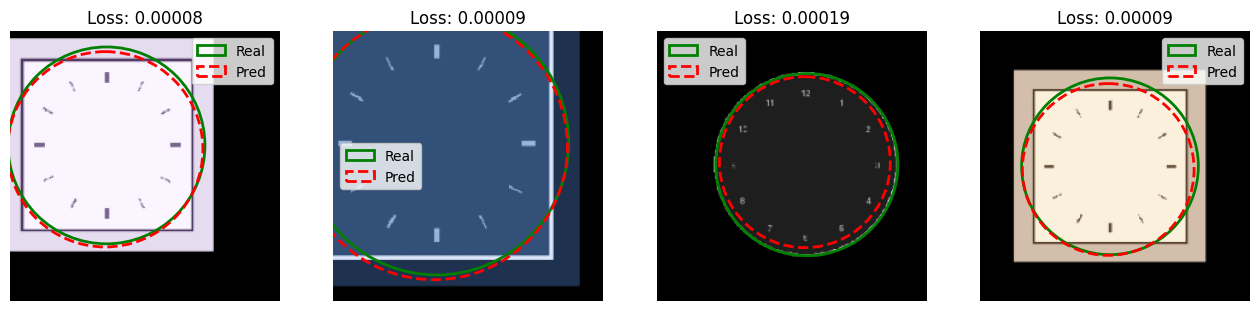

In [15]:
# ==========================================
# CELL 6: Visualize Results (Sanity Check)
# ==========================================

def visualize_prediction():
    # Load model
    model = ClockGeometryNet().to(device)
    try:
        model.load_state_dict(torch.load("checkpoints/geometry_best.pth", map_location=device))
        print("Loaded best model.")
    except:
        print("Model not found. Run training first.")
        return

    model.eval()
    
    # Load one batch from Test set
    ds = GeometryDataset("../data", subset='test')
    loader = DataLoader(ds, batch_size=4, shuffle=True)
    images, labels = next(iter(loader))
    
    images = images.to(device)
    with torch.no_grad():
        preds = model(images).cpu() # Get predictions
        
    images = images.cpu()
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        ax = axes[i]
        # Convert tensor image back to numpy for plotting
        img_np = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        
        h, w, _ = img_np.shape
        
        # Draw Ground Truth (Green)
        gt_x, gt_y, gt_r = labels[i]
        gt_circle = plt.Circle((gt_x * w, gt_y * h), gt_r * w, color='green', fill=False, linewidth=2, label='Real')
        ax.add_patch(gt_circle)
        
        # Draw Prediction (Red)
        p_x, p_y, p_r = preds[i]
        pred_circle = plt.Circle((p_x * w, p_y * h), p_r * w, color='red', fill=False, linewidth=2, linestyle='--', label='Pred')
        ax.add_patch(pred_circle)
        
        ax.legend()
        ax.set_title(f"Loss: {nn.MSELoss()(preds[i], labels[i]):.5f}")
        ax.axis('off')
    
    plt.show()

# Visualize
visualize_prediction()